# Classification workflow : Loan Approval Project

## Import Required Libraries


In [1]:
import pandas as pd
import numpy  as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings   # to ignore any warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
train = pd.read_csv('loan_sanction_train.csv')
test = pd.read_csv('loan_sanction_test.csv')

In [3]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [4]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Let's make copy of train and test data so that even if we have to make any changes in these datasets we would not lose the original datasets.

In [6]:
train_original = train.copy()
test_original = test.copy()

In [7]:
train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [8]:
test.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [9]:
# print data types for each variable
train.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [10]:
# shape of the dataset
train.shape, test.shape

((614, 13), (367, 12))

# EDA

## Univariate analysis

### Target Variable

As it's a categorical variable let us look at its frequency table, percentage distribution and bar plot.

In [11]:
train['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [12]:
# Normalize can be set to True to print proportions insted of numbers.
train['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

<Axes: xlabel='Loan_Status'>

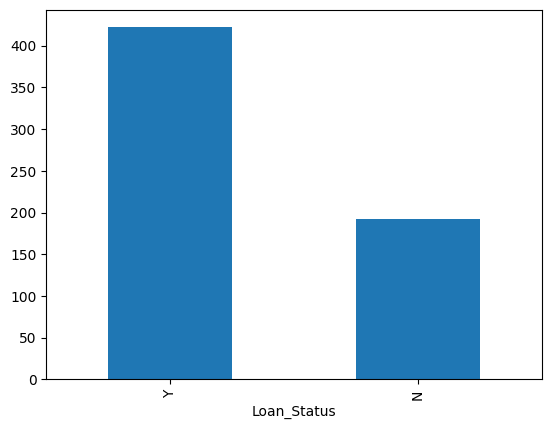

In [13]:
train['Loan_Status'].value_counts().plot.bar()

Now lets visualize each variable separately.

1. **Categorical features** These features have categories (`Gender`, `Married`, `Self_Employed`, `Credit_History`,`Loan_Status`)

2. **Ordinal features:** Variables in categorical features having some order involved (Dependents, Education, Property_Area)

3. **Numerical features** These features have numerical values (ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term)


Lets visualize the categorical and ordinal features first.

## Independent variable (Categorical)

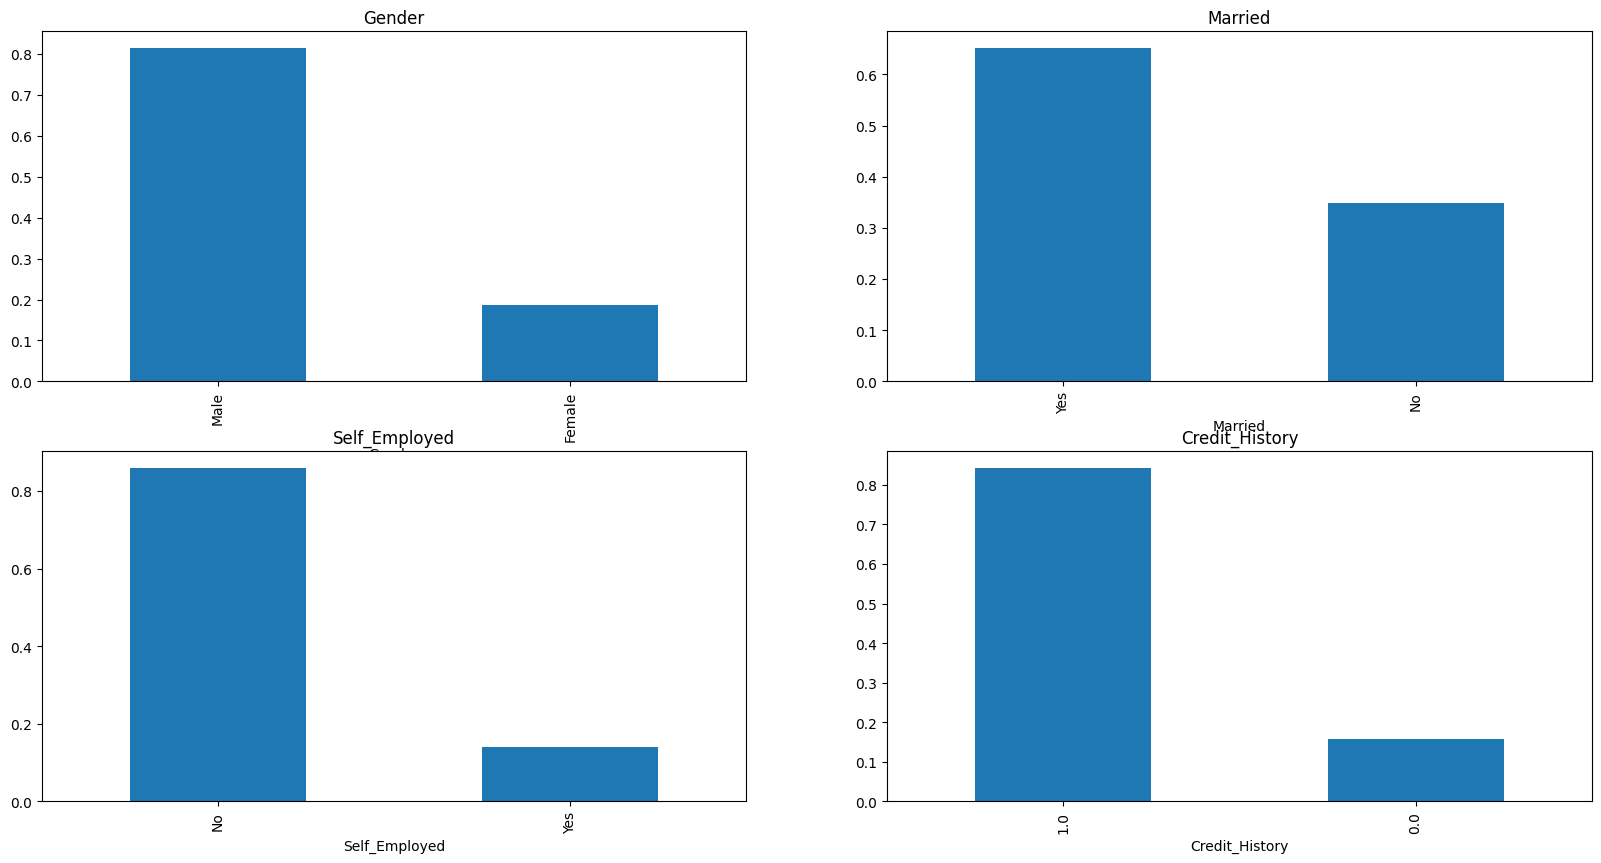

In [14]:
plt.figure(1)
plt.subplot(221) # plt.subplot(nrows, ncols, plot_number)
train['Gender'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Gender')

plt.subplot(222)
train['Married'].value_counts(normalize=True).plot.bar(title= 'Married')

plt.subplot(223)
train['Self_Employed'].value_counts(normalize=True).plot.bar(title= 'Self_Employed')

plt.subplot(224)
train['Credit_History'].value_counts(normalize=True).plot.bar(title= 'Credit_History')

plt.show()

It can be inferred from the above bar plots that:

- 80% applicants in the dataset are male.

- Around 65% of the applicants in the dataset are married.

- Around 15% applicants in the dataset are self employed.

- Around 85% applicants have repaid their debts.

### Independent Variable (Ordinal)

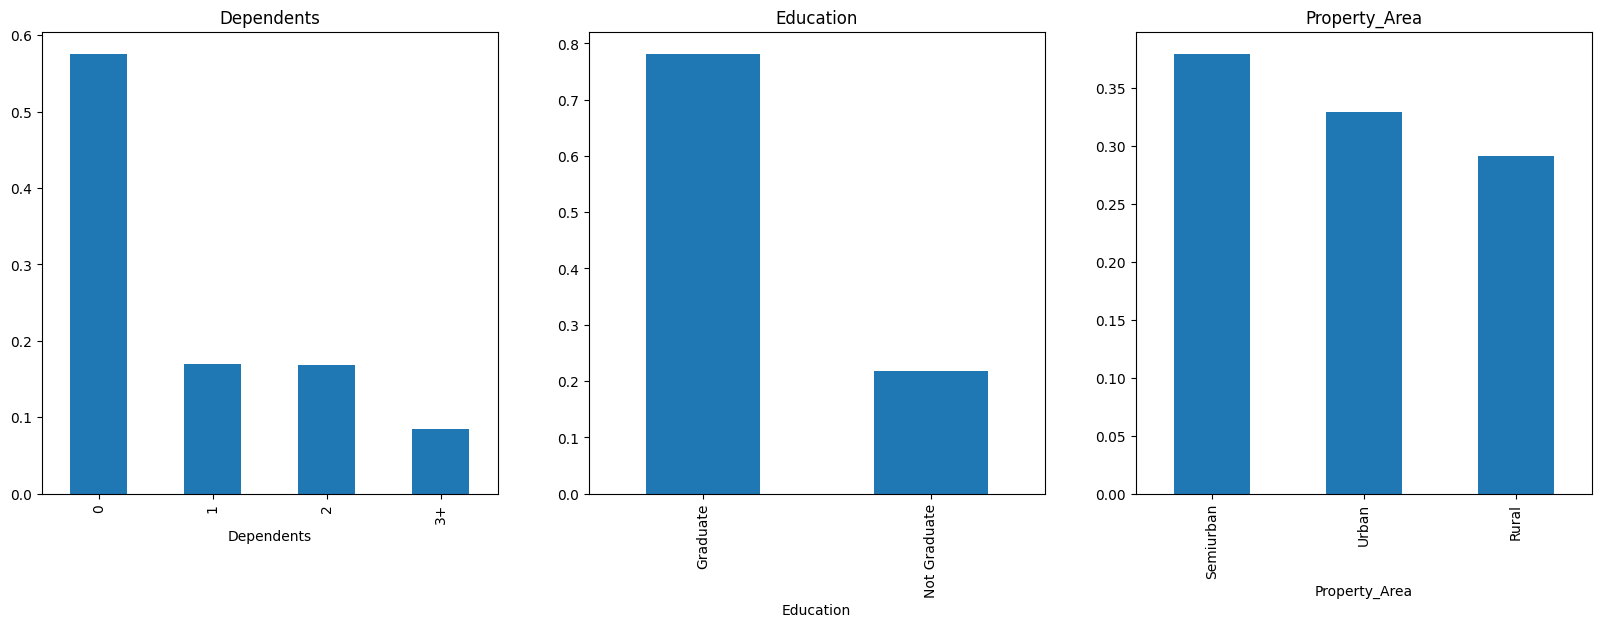

In [15]:
plt.figure(1)
plt.subplot(131)
train['Dependents'].value_counts(normalize=True).plot.bar(figsize = (20,6), title='Dependents')

plt.subplot(132)
train['Education'].value_counts(normalize=True).plot.bar(title= 'Education')

plt.subplot(133)
train['Property_Area'].value_counts(normalize=True).plot.bar(title= 'Property_Area')

plt.show()

## Independent variable (Numerical)

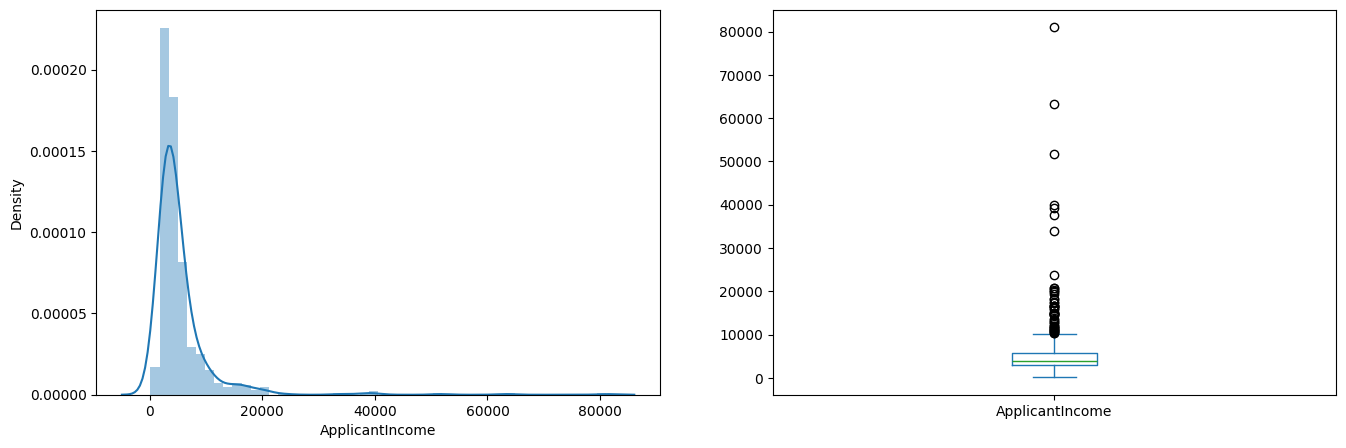

In [16]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['ApplicantIncome'])

plt.subplot(122)
train['ApplicantIncome'].plot.box(figsize=(16,5))

plt.show()

- Applicant income is not normally distributed. We should make it normal as algorithm works better if the data is normally distributed.

- Boxplot confirms the presence of outliers/extreme values. This can be attributed to the income disparity in the society.
- Lets segregate them by Education

Text(0.5, 0.98, '')

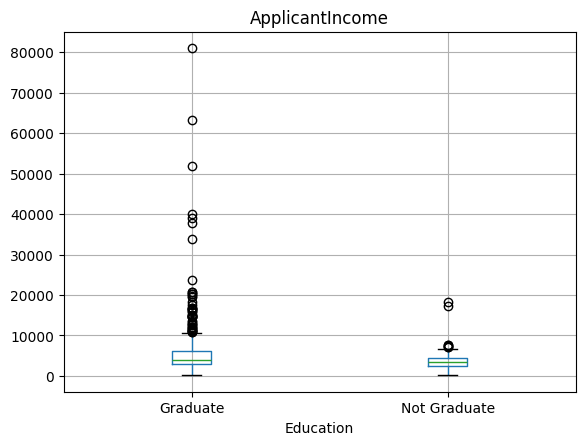

In [17]:
train.boxplot(column="ApplicantIncome", by = "Education")
plt.suptitle("")

 - There are more graduates with very high incomes compared to non-graduates, and these high-income values are represented as outliers.

 - This indicates that some graduates earn significantly more than the typical range, which skews their distribution.

- Lets look at the coapplicant income distribution.

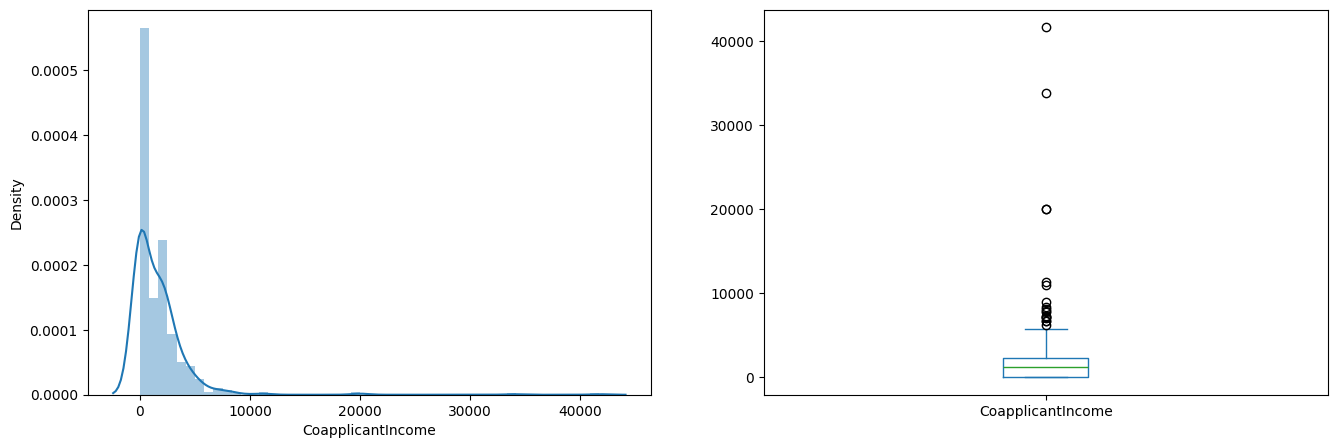

In [18]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['CoapplicantIncome'])
plt.subplot(122)
train['CoapplicantIncome'].plot.box(figsize=(16,5))
plt.show()

Coapplicants income is not normally distributed.

Lets look at distribution of loan amount

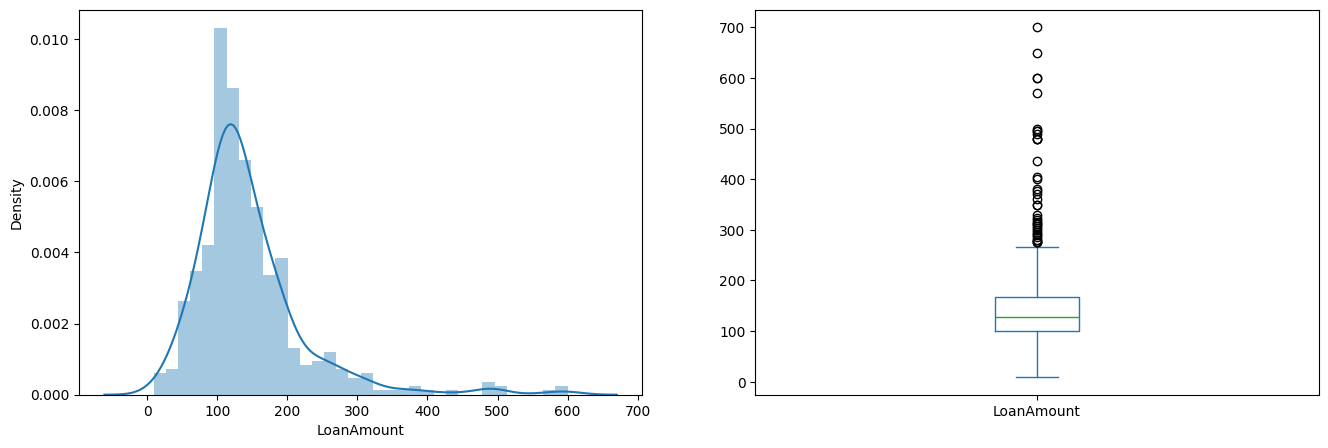

In [19]:
plt.figure(1)
plt.subplot(121)
df = train.dropna()
sns.distplot(df['LoanAmount'])

plt.subplot(122)
train['LoanAmount'].plot.box(figsize=(16,5))

plt.show()

Distribution is fairly normal. Lot of outliers

Now lets check how each feature correlate with Loan Status.

## Bivariate Analysis

## Categorical Independent Variable v/s Target Variable

<Axes: xlabel='Gender'>

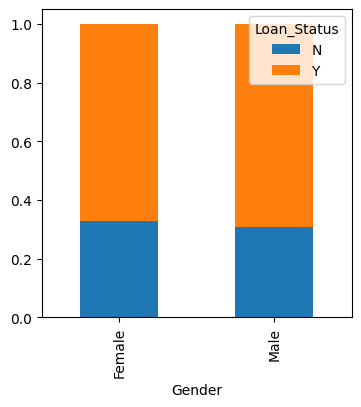

In [20]:
Gender = pd.crosstab(train['Gender'], train['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

Proportion of female and male applicants is more or less same for both approved and unapproved loans.

Now visualize the remaining categorical variables vs target variable.

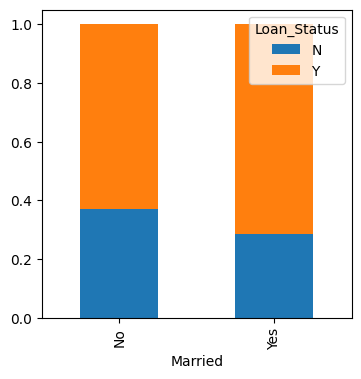

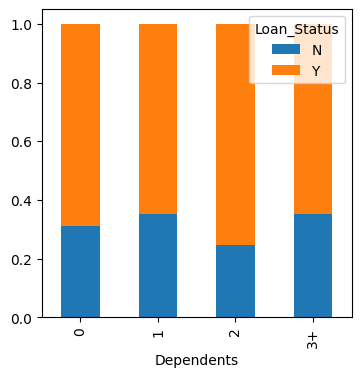

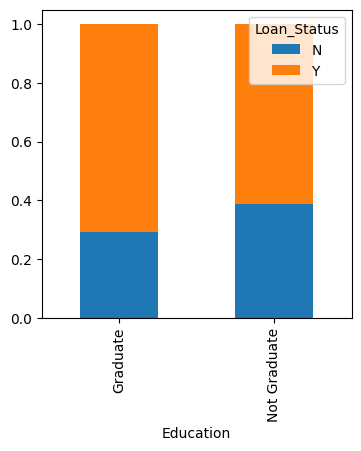

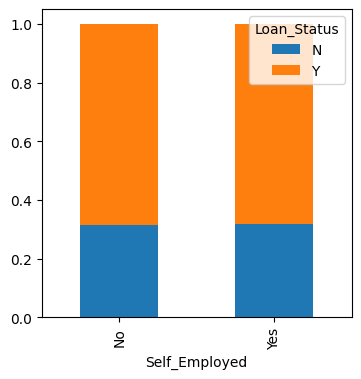

In [21]:
Married = pd.crosstab(train['Married'],train['Loan_Status'])
Dependents = pd.crosstab(train['Dependents'],train['Loan_Status'])
Education = pd.crosstab(train['Education'],train['Loan_Status'])
Self_Employed = pd.crosstab(train['Self_Employed'],train['Loan_Status'])

Married.div(Married.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

- Proportion of married applicant is higher for the approved loans.
- Distribution of applicant with 1 or 3+ dependets is similar accross both the categories of Loan_Status
- There is nothing significant we can infer from Self_Employed vs Loan_Status plot

Relationship between remaining categorical independent variables and Loan_Status

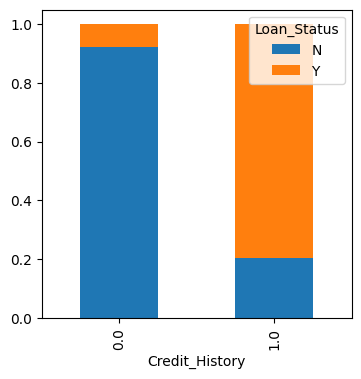

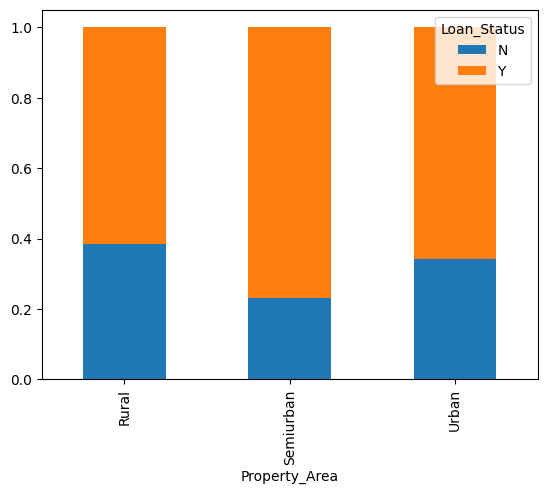

In [22]:
Credit_History = pd.crosstab(train['Credit_History'], train['Loan_Status'])
Property_Area = pd.crosstab(train['Property_Area'], train['Loan_Status'])

Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.show()

## Numerical Independent Variable vs Target Variable

We will try to find the mean income of people for which the loan has approved vs mean income of people for which the has not approved.

<Axes: xlabel='Loan_Status'>

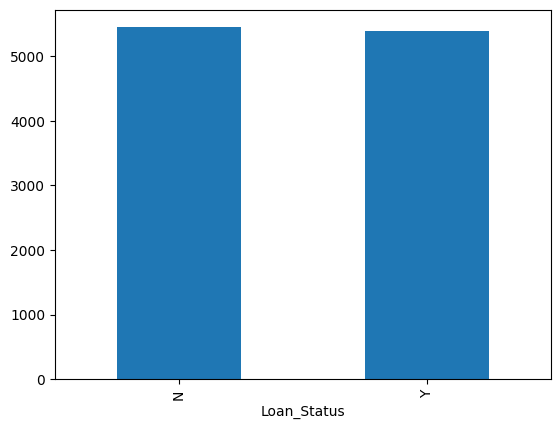

In [23]:
train.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

lets make bins for the applicant income variable based on the values in it and analyze the corresponding loan status for each bin

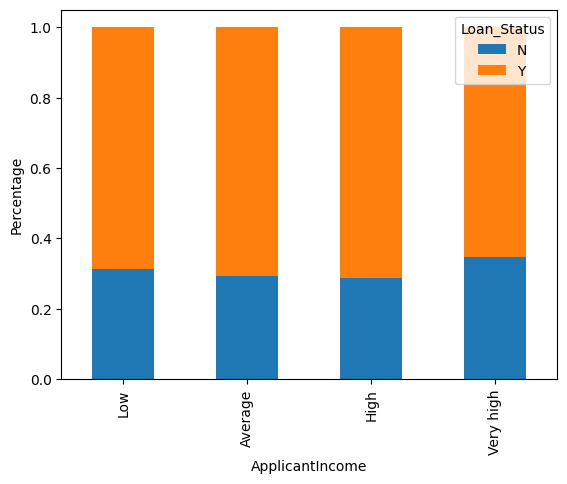

In [24]:
bins=[0,2500,4000,6000,81000]
group=['Low','Average','High', 'Very high']


train['Income_bin']=pd.cut(df['ApplicantIncome'],bins,labels=group)

Income_bin=pd.crosstab(train['Income_bin'],train['Loan_Status'])

Income_bin.div(Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)

plt.xlabel('ApplicantIncome')
P = plt.ylabel('Percentage')

analyze the coapplicant income and loan amount variable

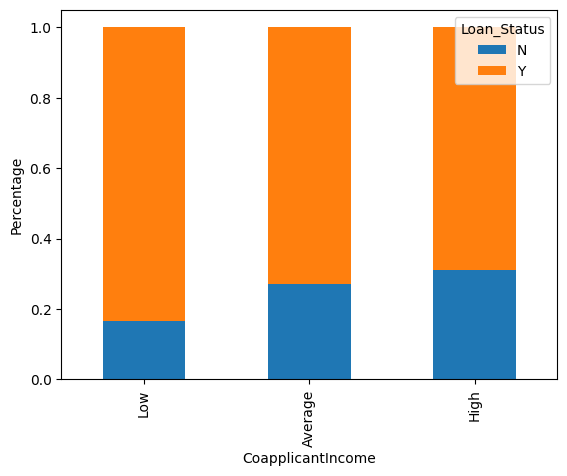

In [25]:
bins = [0,1000,3000,42000]
group = ['Low', 'Average', 'High']

train['Coapplicant_Income_bin'] = pd.cut(df['CoapplicantIncome'],bins,labels=group)

Coapplicant_Income_bin=pd.crosstab(train['Coapplicant_Income_bin'],train['Loan_Status'])
Coapplicant_Income_bin.div(Coapplicant_Income_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)

plt.xlabel('CoapplicantIncome')
P = plt.ylabel('Percentage')

It shows that coapplicants income is less the chances of loan approval are high. Let us combine the Applicant Income and Coapplicant Income and see the combined effect of Total_Income on the Loan_Status.

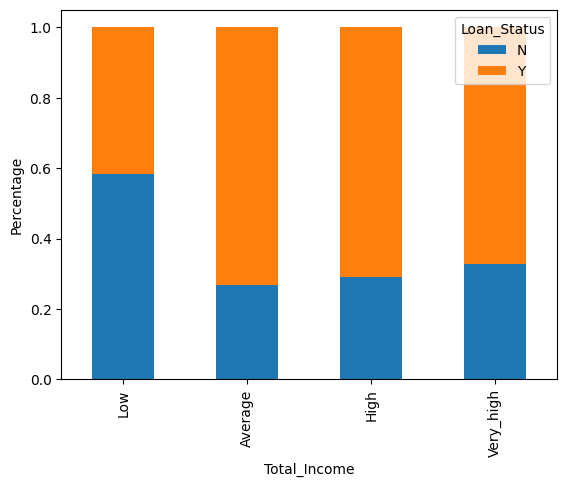

In [26]:
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']

bins = [0,2500,4000,6000,81000]
group = ['Low', 'Average', 'High', 'Very_high']

train['Total_Income_bin']=pd.cut(train['Total_Income'],bins,labels=group)

Total_Income_bin=pd.crosstab(train['Total_Income_bin'],train['Loan_Status'])
Total_Income_bin.div(Total_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)

plt.xlabel('Total_Income')
P = plt.ylabel('Percentage')

We can see that Proportion of loans getting approved for applicants having low Total_Income is very less as compared to that of applicants with Average, High and Very High Income.

Let’s visualize the Loan amount variable.

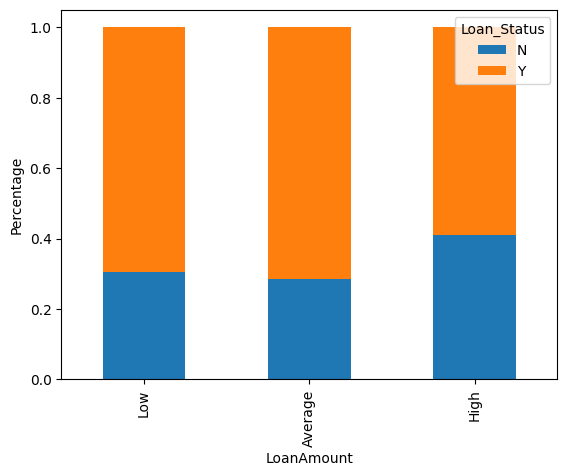

In [27]:
bins=[0,100,200,700]
group=['Low','Average','High']

train['LoanAmount_bin']=pd.cut(df['LoanAmount'],bins,labels=group)

LoanAmount_bin=pd.crosstab(train['LoanAmount_bin'],train['Loan_Status'])
LoanAmount_bin.div(LoanAmount_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)

plt.xlabel('LoanAmount')
P = plt.ylabel('Percentage')

<Axes: xlabel='Property_Area', ylabel='LoanAmount'>

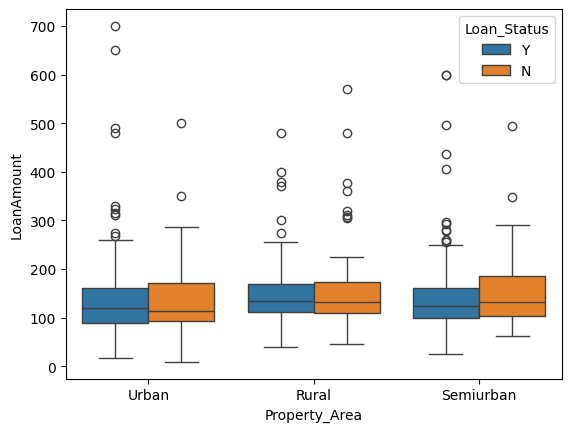

In [28]:
# loan amount vs property area
sns.boxplot(x='Property_Area', y='LoanAmount', hue='Loan_Status', data=train)

<Axes: xlabel='Property_Area', ylabel='ApplicantIncome'>

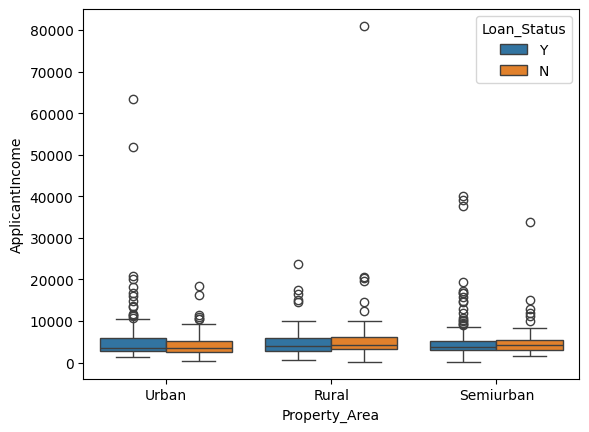

In [29]:
# income vs property area
sns.boxplot(x='Property_Area', y='ApplicantIncome', hue='Loan_Status', data=train)

<Axes: xlabel='Credit_History'>

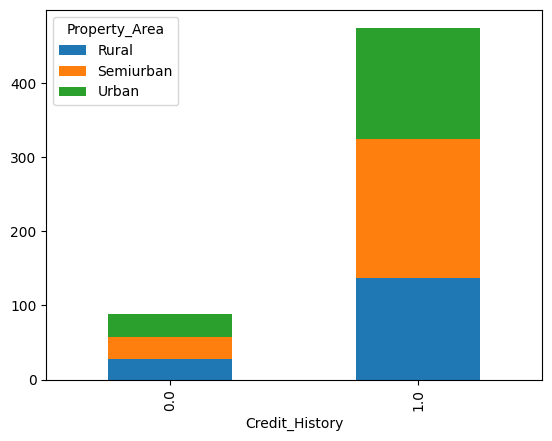

In [30]:
# credit history vs property area bar plot
pd.crosstab(train['Credit_History'], train['Property_Area']).plot(kind='bar',stacked=True)

In [31]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,Coapplicant_Income_bin,Total_Income,Total_Income_bin,LoanAmount_bin
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,NaN,NaN,5849.0,High,NaN
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,High,Average,6091.0,Very_high,Average
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,Average,NaN,3000.0,Average,Low
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,Average,Average,4941.0,High,Average
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,High,NaN,6000.0,High,Average


In [32]:
train = train.drop(['Income_bin', 'Coapplicant_Income_bin', 'LoanAmount_bin', 'Total_Income'], axis=1)

In [33]:
train['Dependents'].replace('3+', 3,inplace=True)
test['Dependents'].replace('3+', 3,inplace=True)
train['Loan_Status'].replace('N', 0,inplace=True)
train['Loan_Status'].replace('Y', 1,inplace=True)

Now lets look at the correlation between all the numerical variables. We will use the heat map to visualize the correlation. Heatmaps visualize data through variations in coloring. The variables with darker color means their correlation is more.


In [34]:
numerical_df = train.select_dtypes(include=['int64', 'float64'])

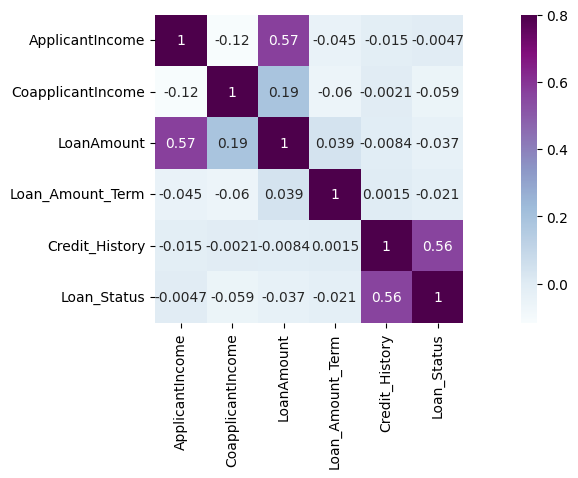

In [35]:
matrix = numerical_df.corr()
f, ax = plt.subplots(figsize=(15,4))
sns.heatmap(matrix, vmax=.8, square=True, cmap="BuPu", annot=True);

## Missing Value Imputation

In [36]:
train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
Total_Income_bin      0
dtype: int64

In [37]:
train.isna().sum().sum()

np.int64(149)

In [38]:
test.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [39]:
test.isna().sum().sum()

np.int64(84)

In [40]:
train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
train['Married'].fillna(train['Married'].mode()[0], inplace=True)
train['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
train['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)
train['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)

In [41]:
test['Gender'].fillna(test['Gender'].mode()[0], inplace=True)
test['Married'].fillna(test['Married'].mode()[0], inplace=True)
test['Dependents'].fillna(test['Dependents'].mode()[0], inplace=True)
test['Self_Employed'].fillna(test['Self_Employed'].mode()[0], inplace=True)
test['Credit_History'].fillna(test['Credit_History'].mode()[0], inplace=True)

In [42]:
train['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [43]:
train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace=True)
test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].mode()[0], inplace=True)

In [44]:
train['LoanAmount'].fillna(train['LoanAmount'].mode()[0], inplace=True)
test['LoanAmount'].fillna(test['LoanAmount'].mode()[0], inplace=True)

In [45]:
train.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Total_Income_bin     0
dtype: int64

In [46]:
test.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

# Outlier Treatment

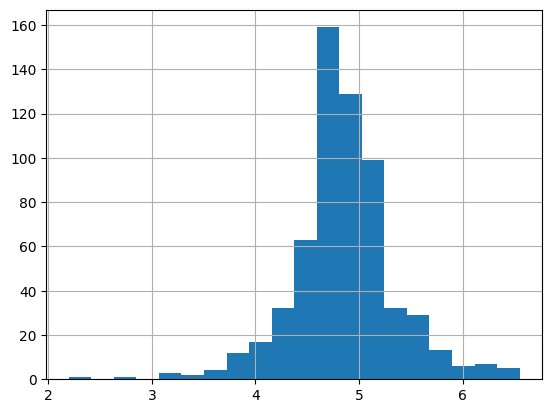

In [47]:
train['LoanAmount_log'] = np.log(train['LoanAmount'])
train['LoanAmount_log'].hist(bins=20)
test['LoanAmount_log'] = np.log(test['LoanAmount'])

### Feature Engineering

In [48]:
train.set_index('Loan_ID', inplace=True)
test.set_index('Loan_ID', inplace=True)

In [49]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income_bin,LoanAmount_log
Loan_ID,,,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,1,High,4.787492
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,Very_high,4.852030
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,Average,4.189655
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,High,4.787492
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,High,4.948760


In [50]:
train.drop(['Total_Income_bin', 'LoanAmount_log'], axis=1, inplace=True)
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,1
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [51]:
test.drop(['LoanAmount_log'], axis=1, inplace=True)
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,1
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [52]:
print(train.columns)
print(test.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


### Categorical Feature Encoding

In [53]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,1
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [54]:
train['Gender'] = train['Gender'].map({'Male':1, 'Female':0})
train['Married'] = train['Married'].map({'Yes':1, 'No':0})
train['Education'] = train['Education'].map({'Graduate':1, 'Not Graduate':0})
train['Self_Employed'] = train['Self_Employed'].map({'Yes':1, 'No':0})

In [55]:
test['Gender'] = test['Gender'].map({'Male':1, 'Female':0})
test['Married'] = test['Married'].map({'Yes':1, 'No':0})
test['Education'] = test['Education'].map({'Graduate':1, 'Not Graduate':0})
test['Self_Employed'] = test['Self_Employed'].map({'Yes':1, 'No':0})

In [56]:
train['Dependents'].unique()

array(['0', '1', '2', 3], dtype=object)

In [57]:
train['Dependents'] = train['Dependents'].replace('3+', 3).astype(int)

In [58]:
test['Dependents'] = test['Dependents'].replace('3+', 3).astype(int)

In [59]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,Urban,1
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1


## One hot Encoding

In [60]:
trian_df_encoded = pd.get_dummies(train, columns=['Property_Area'], drop_first=True)

In [61]:
test_df_encoded = pd.get_dummies(test, columns=['Property_Area'], drop_first=True)

In [62]:
trian_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,1,False,True
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


In [63]:
trian_df_encoded = trian_df_encoded.astype(int)

In [64]:
test_df_encoded = test_df_encoded.astype(int)

In [65]:
trian_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0,120,360,1,1,0,1
LP001003,1,1,1,1,0,4583,1508,128,360,1,0,0,0
LP001005,1,1,0,1,1,3000,0,66,360,1,1,0,1
LP001006,1,1,0,0,0,2583,2358,120,360,1,1,0,1
LP001008,1,0,0,1,0,6000,0,141,360,1,1,0,1


### Label Encoding

In [66]:
from sklearn.preprocessing import LabelEncoder

In [67]:
le = LabelEncoder()

train['Property_Area'] = le.fit_transform(train['Property_Area'])
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,2,1
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [68]:
test['Property_Area'] = le.fit_transform(test['Property_Area'])
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


# Building Model

### Using Label Encoded Data

In [69]:
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

In [70]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,120.0,360.0,1.0,2
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0
LP002979,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,0
LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,2


In [71]:
y

Loan_ID
LP001002    1
LP001003    0
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    0
Name: Loan_Status, Length: 614, dtype: int64

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


# Build KNN Model

In [75]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [76]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [77]:
print("KNN train score:", knn.score(X_train, y_train))
print("KNN test score:", knn.score(X_test, y_test))

KNN train score: 0.7352342158859471
KNN test score: 0.5772357723577236


In [78]:
scores = []
for k in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

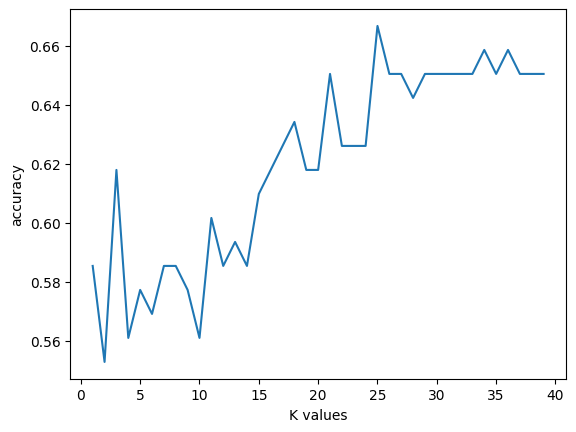

In [79]:
plt.plot(range(1,40), scores)
plt.xlabel("K values")
plt.ylabel("accuracy")
plt.show()

In [80]:
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train, y_train)
print("KNN train score:", knn.score(X_train, y_train))
print("KNN test score:", knn.score(X_test, y_test))
y_pred = knn.predict(X_test)

KNN train score: 0.7087576374745418
KNN test score: 0.6666666666666666


In [81]:
KNN_accuracy = accuracy_score(y_test, y_pred)

In [82]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.05      0.09        43
           1       0.66      1.00      0.80        80

    accuracy                           0.67       123
   macro avg       0.83      0.52      0.44       123
weighted avg       0.78      0.67      0.55       123



# Build SVM Model

In [83]:
from sklearn.svm import SVC

In [84]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [85]:
print("SVM train score:", svm.score(X_train, y_train))
print("SVM test score:", svm.score(X_test, y_test))

SVM train score: 0.7881873727087576
SVM test score: 0.7723577235772358


In [86]:
y_pred = svm.predict(X_test)
SVM_accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.35      0.52        43
           1       0.74      1.00      0.85        80

    accuracy                           0.77       123
   macro avg       0.87      0.67      0.68       123
weighted avg       0.83      0.77      0.73       123



# Build Decision Tree

In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [89]:
print("DT train score:", dt.score(X_train, y_train))
print("DT test score:", dt.score(X_test, y_test))

DT train score: 0.8207739307535642
DT test score: 0.7886178861788617


In [90]:
y_pred = dt.predict(X_test)
DT_accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



# Model Performance on Test Data

In [91]:
test_predictions_knn = knn.predict(test)
output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'], 'Loan_Status': test_predictions_knn})
output.to_csv('test_predictions_knn.csv', index=False)

In [92]:
test_predictions_svm = svm.predict(test)
output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'], 'Loan_Status': test_predictions_svm})
output.to_csv('test_predictions_svm.csv', index=False)

In [93]:
test_predictions_dt = dt.predict(test)
output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'], 'Loan_Status': test_predictions_dt})
output.to_csv('test_predictions_dt.csv', index=False)

 ## Model Comparison

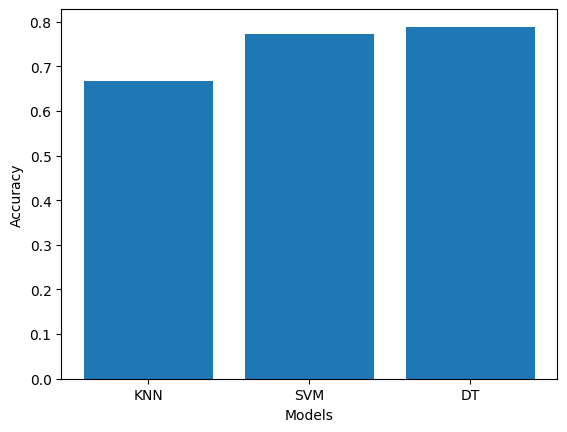

In [94]:
models = ['KNN', 'SVM', 'DT']
accuracy = [KNN_accuracy, SVM_accuracy, DT_accuracy]
plt.bar(models, accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# Feature Importance 2

## Outlier Treatment

In [95]:
train['ApplicantIncome_log'] = np.log(train['ApplicantIncome'])
train['LoanAmount_log'] = np.log(train['LoanAmount'])

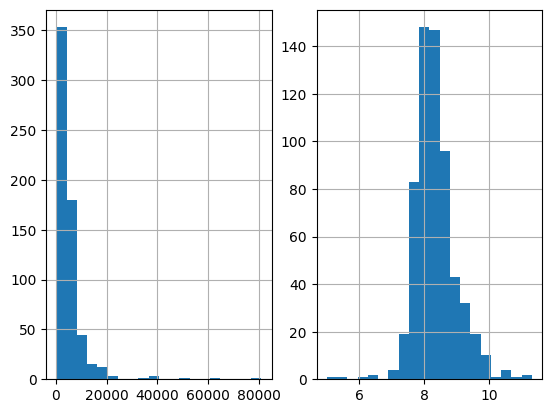

In [96]:
plt.figure(1)

plt.subplot(1,2,1)
train['ApplicantIncome'].hist(bins=20) 

plt.subplot(1,2,2)
train['ApplicantIncome_log'].hist(bins=20) 

plt.show()

In [97]:
train['CoapplicantIncome_log_offset'] = np.log(train['CoapplicantIncome']+1)

In [98]:
train['CoapplicantIncome_log'] = np.sqrt(train['CoapplicantIncome'])

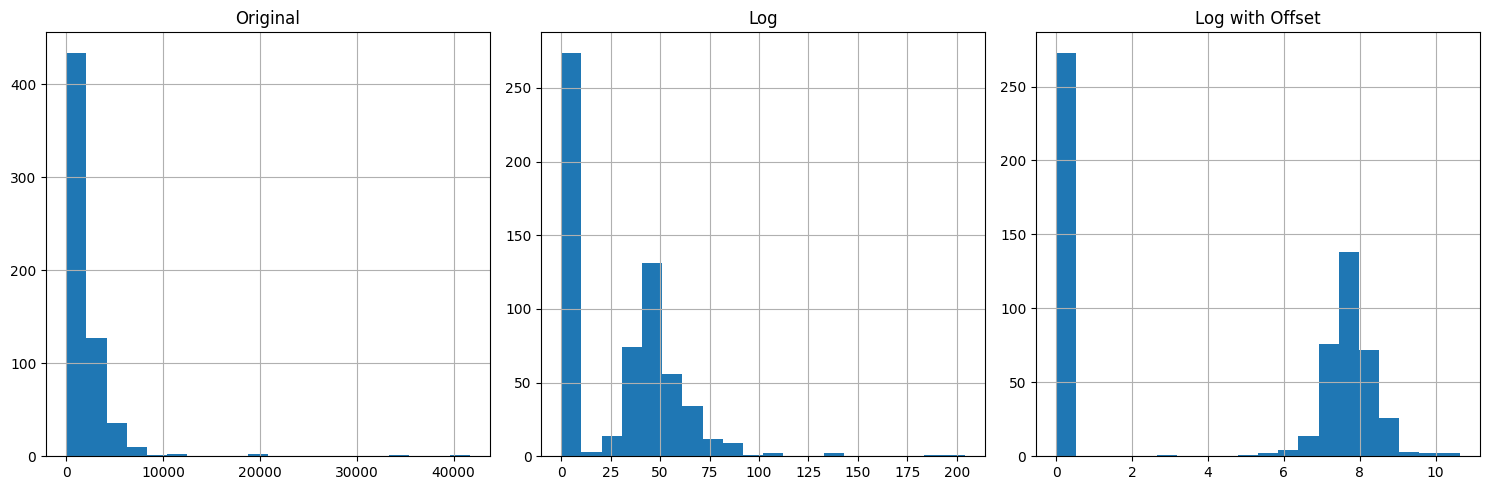

In [99]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
train['CoapplicantIncome'].hist(bins=20)
plt.title('Original')

plt.subplot(1,3,2)
train['CoapplicantIncome_log'].hist(bins=20)
plt.title('Log')

plt.subplot(1,3,3)
train['CoapplicantIncome_log_offset'].hist(bins=20)
plt.title('Log with Offset')

plt.tight_layout()
plt.show()


In [100]:
train.drop(['ApplicantIncome', 'CoapplicantIncome', 'CoapplicantIncome_log_offset', 'LoanAmount'], axis=1, inplace=True)

In [101]:
test['ApplicantIncome_log'] = np.log(test['ApplicantIncome'])
test['LoanAmount_log'] = np.log(test['LoanAmount'])
test['CoapplicantIncome_log'] = np.sqrt(test['CoapplicantIncome'])

In [102]:
test.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'], axis=1, inplace=True)

## Feature Importance: Base Model

In [103]:
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
DT_accuracy = accuracy_score(y_pred, y_test)
print('DT Accuracy:', DT_accuracy)

DT Accuracy: 0.7886178861788617


In [106]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
DT_accuracy = accuracy_score(y_pred, y_test)
print('SVM Accuracy:', SVM_accuracy)

SVM Accuracy: 0.7723577235772358


## Feature Importance: LOFO on Decision Tree

In [107]:
feature_importance = {}

for feature in X.columns:
    X_train_reduced = X_train.drop(feature, axis=1)
    X_test_reduced = X_test.drop(feature, axis=1)

    dt.fit(X_train_reduced, y_train)

    y_pred = dt.predict(X_test_reduced)
    reduced_accuracy = accuracy_score(y_pred, y_test)

    performance_drop = DT_accuracy - reduced_accuracy
    feature_importance[feature] = performance_drop

for feature, drop in feature_importance.items():
    print(f"{feature}: Performance Drop = {drop:.4f}")

Gender: Performance Drop = 0.0000
Married: Performance Drop = 0.0000
Dependents: Performance Drop = 0.0000
Education: Performance Drop = 0.0000
Self_Employed: Performance Drop = 0.0000
Loan_Amount_Term: Performance Drop = 0.0000
Credit_History: Performance Drop = 0.1545
Property_Area: Performance Drop = 0.0000
ApplicantIncome_log: Performance Drop = 0.0000
LoanAmount_log: Performance Drop = 0.0000
CoapplicantIncome_log: Performance Drop = 0.0000


## Feature Importance: LOFO on SVM

In [108]:
feature_importance = {}

for feature in X.columns:
    X_train_reduced = X_train.drop(feature, axis=1)
    X_test_reduced = X_test.drop(feature, axis=1)

    svm.fit(X_train_reduced, y_train)

    y_pred = svm.predict(X_test_reduced)
    reduced_accuracy = accuracy_score(y_pred, y_test)

    performance_drop = SVM_accuracy - reduced_accuracy
    feature_importance[feature] = performance_drop

for feature, drop in feature_importance.items():
    print(f"{feature}: Performance Drop = {drop:.4f}")

Gender: Performance Drop = -0.0163
Married: Performance Drop = -0.0163
Dependents: Performance Drop = -0.0163
Education: Performance Drop = -0.0163
Self_Employed: Performance Drop = -0.0163
Loan_Amount_Term: Performance Drop = -0.0163
Credit_History: Performance Drop = 0.1220
Property_Area: Performance Drop = -0.0163
ApplicantIncome_log: Performance Drop = -0.0163
LoanAmount_log: Performance Drop = -0.0163
CoapplicantIncome_log: Performance Drop = -0.0163


# Feature Importance: Interpretation
- Credit_History (Performance Drop = 0.1545):

1. This feature has the highest performance drop, meaning it is the most critical predictor for the model's accuracy.
2. Removing this feature significantly impacts the model's ability to make correct predictions.

- Other Features (Performance Drop = 0.0000):

1. For all other features (Gender, Married, Dependents, Education, etc.), the performance drop is zero.
2. This suggests that these features do not contribute significantly to the model's predictions. In essence, the model's performance remains unchanged even if these features are excluded.

## Build Final ML Model with Hyperparameter Tuning

In [109]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [110]:
X = train[['Loan_Amount_Term','Credit_History','ApplicantIncome_log','LoanAmount_log','CoapplicantIncome_log']]
Y = train['Loan_Status']

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [112]:
# Train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion='entropy',
                                  random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [113]:
# hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_leaf_nodes': [10, 20, 50]
}

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs = -1, # use all cpu cores
                           verbose = 2 # print progress
                           )

In [114]:
# Fit Grid Search to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_leaf_nodes': [10, 20, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [115]:
# Display the best parameters found by GridSearchCV
print("Best Hyperparameters from Grid Search:", grid_search.best_params_)

Best Hyperparameters from Grid Search: {'max_depth': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}


In [116]:
# Evaluate the model with the best parameters on the test set
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(X_test)

In [117]:
# Predict on training and testing data
train_preds = best_dt_model.predict(X_train)
test_preds = best_dt_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8147
Testing Accuracy: 0.7805


In [118]:
print("Classification Report (Grid Search):")
print(classification_report(y_test, y_pred))

Classification Report (Grid Search):
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123



In [119]:
# hyperparameter distribution
from scipy.stats import randint

param_dist = {
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_leaf_nodes': randint(10, 100)
}

In [120]:
# initialize random search
random_search = RandomizedSearchCV(estimator=dt_model,
                                   param_distributions=param_dist,
                                   n_iter=100,  #number of iterations
                                   cv=5,
                                   scoring='accuracy',
                                   n_jobs=-1,
                                   verbose=2
                                  )

In [121]:
# Fit Random Search to the training data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....00249A4BDB500>, 'max_leaf_nodes': <scipy.stats....00249A4FFA480>, 'min_samples_leaf': <scipy.stats....00249A4FA07A0>, 'min_samples_split': <scipy.stats....00249A4FA1970>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Gu

In [122]:
# Display the best parameters found by RandomizedSearchCV
print("Best Hyperparameters from Random Search:", random_search.best_params_)

Best Hyperparameters from Random Search: {'max_depth': 10, 'max_leaf_nodes': 10, 'min_samples_leaf': 19, 'min_samples_split': 18}


In [123]:
# Evaluate the model with the best parameters on the test set
best_dt_model_random = random_search.best_estimator_
y_pred_random = best_dt_model_random.predict(X_test)

In [124]:
# Predict on training and testing data
train_preds = best_dt_model_random.predict(X_train)
test_preds = best_dt_model_random.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred_random)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8167
Testing Accuracy: 0.7480


In [125]:
print("Classification Report (Random Search):")
print(classification_report(y_test, y_pred_random))

Classification Report (Random Search):
              precision    recall  f1-score   support

           0       0.71      0.47      0.56        43
           1       0.76      0.90      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123



## Hyperparameter on SVM

In [126]:
svm = SVC()

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf'],  # Kernel type
    'gamma': ['scale', 0.1]  # Kernel coefficient
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=svm,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=10,
                          n_jobs=-1)

grid_search.fit(X_train, y_train)

# Best parameters and performance
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluate on test set
svm_model = grid_search.best_estimator_
y_pred = svm_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Score: 0.8145949288806431
Test Accuracy: 0.7886178861788617


## 📊 Conclusion

- Decision Tree shows overfitting (Train: 0.8167, Test: 0.7480)
- Base SVM performs better (Test: 0.7724)
- Tuned SVM gives best results (Test: 0.7886)

➡️ Tuned SVM (Linear, C = 0.1) is the best model.
